# SokoPrice: AI Grocery Price Forecasting for Kigali Informal Markets
### BSc. Software Engineering
| | |
|---|---|
| **Author** | Nice Eva Karabaranga |
| **Supervisor** | Hubert Apana |
| **Date** | June 2026 |
| **Dataset** | WFP VAM Kenya Food Prices (Alternative data for Kigali) |
| **Methodology** | CRISP-DM |

---

### Secondary Data Justification
WFP VAM Kenya dataset was used as a feasibility alternative. Kenya and Rwanda share comparable
informal market structures, the same staple food basket, and similar price volatility patterns.
Real Kigali data will be collected later after proving the feasibility of the project and knowing what data needs to be corrected. 

---
## Phase 0 - Set up the Environment 

In [1]:
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'scipy==1.15.3', 'seaborn==0.13.2',
    '-q', '--upgrade', '--no-deps'
], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'scipy==1.15.3', 'seaborn==0.13.2', '-q', '--upgrade', '--no-deps'], returncode=0)

---
## Phase 1 - Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import json, joblib
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

SP_GREEN  = '#2ECC71'
SP_DARK   = '#1A252F'
SP_ACCENT = '#E67E22'
PALETTE   = [SP_GREEN, SP_ACCENT, '#3498DB', '#9B59B6', '#E74C3C', '#1ABC9C', '#F39C12', '#2980B9']

print('All imports loaded')
print(f'numpy {np.__version__} | pandas {pd.__version__} | seaborn {sns.__version__} | tensorflow {tf.__version__}')

E0000 00:00:1781397428.407094    1204 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781397428.415113    1204 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781397428.434519    1204 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781397428.434539    1204 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781397428.434541    1204 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781397428.434544    1204 computation_placer.cc:177] computation placer already registered. Please check linka

All imports loaded
numpy 2.4.6 | pandas 2.3.3 | seaborn 0.13.2 | tensorflow 2.19.0


---
## Phase 2 - Business Understanding

### SokoPrice Goals
| Business Goal | ML Translation | Output |
|---|---|---|
| Forecast grocery prices 7 days ahead | Regression / Time-series | Predicted price (KES) |
| Recommend cheapest market | Price comparison + ranking | Sorted market list |
| Estimate basket cost | Aggregated predictions | Total KES |
| Alert users to price spikes | Threshold on predictions | Alert flag |

### Research Hypothesis
> Ensemble methods (Random Forest, XGBoost) will achieve higher forecast accuracy than Linear Regression and LSTM.

### Evaluation Metrics
| Metric | Interpretation |
|---|---|
| **MAE** | Average KES prediction error |
| **RMSE** | Penalises large errors |
| **R²** | Variance explained (0 to 1) |
| **MAPE** | Scale-free % error - primary metric |

---
## Phase 3 - Data Understanding & Visualization

In [3]:
# Load Dataset
DATA_PATH = '/kaggle/working/Initial-software-product/Data/wfp_food_prices_ken.csv'
if not os.path.exists(DATA_PATH):
    for root, dirs, files in os.walk('/kaggle'):
        for f in files:
            if f == 'wfp_food_prices_ken.csv':
                DATA_PATH = os.path.join(root, f)
                break
df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Dataset loaded: 26,745 rows x 16 columns


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47


In [4]:
# Column inventory
print('=== COLUMNS & TYPES ===')
print(df_raw.dtypes.to_string())
print('\n=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
display(pd.DataFrame({'Count': missing, 'Pct %': (missing/len(df_raw)*100).round(2)})[missing > 0])
print('\n=== NUMERIC SUMMARY ===')
display(df_raw.describe())

=== COLUMNS & TYPES ===
date             object
admin1           object
admin2           object
market           object
market_id         int64
latitude        float64
longitude       float64
category         object
commodity        object
commodity_id      int64
unit             object
priceflag        object
pricetype        object
currency         object
price           float64
usdprice        float64

=== MISSING VALUES ===


,Count,Pct %
admin1,68,0.25
admin2,68,0.25
latitude,68,0.25
longitude,68,0.25



=== NUMERIC SUMMARY ===


,market_id,latitude,longitude,commodity_id,price,usdprice
count,26745.000000,26677.000000,26677.000000,26745.000000,26745.000000,26745.000000
mean,4043.404749,0.742034,36.997962,300.343840,1353.476522,12.396316
std,3142.074562,2.283518,2.040410,295.224766,2618.520824,23.295694
min,184.000000,-4.660000,34.360000,50.000000,5.000000,0.039000
25%,1852.000000,-1.270000,34.850000,67.000000,69.850000,0.610000
50%,3254.000000,0.350000,36.780000,148.000000,133.000000,1.050000
75%,5670.000000,3.510000,39.010000,451.000000,1235.000000,11.840000
max,10509.000000,4.620000,41.860000,937.000000,19800.000000,184.820000


In [5]:
# Detect key columns
COMM_COL   = next((c for c in df_raw.columns if 'commodity' in c.lower() and 'id' not in c.lower()), None)
MARKET_COL = next((c for c in df_raw.columns if c.lower() == 'market'), None)
DATE_COL   = next((c for c in df_raw.columns if 'date' in c.lower()), None)
numeric_cols = df_raw.select_dtypes(include='number').columns.tolist()
PRICE_COL  = next((c for c in numeric_cols if 'price' in c.lower() and 'usd' not in c.lower()), numeric_cols[0])
print(f'Commodity: {COMM_COL} | Market: {MARKET_COL} | Date: {DATE_COL} | Price: {PRICE_COL}')

Commodity: commodity | Market: market | Date: date | Price: price


In [6]:
# Filter to SokoPrice target commodities
TARGET_KEYWORDS = ['maize', 'potato', 'tomato', 'bean', 'sorghum', 'onion', 'rice', 'spinach', 'flour', 'cabbage', 'banana']
mask = df_raw[COMM_COL].str.lower().apply(lambda x: any(kw in str(x) for kw in TARGET_KEYWORDS))
df_target = df_raw[mask].copy()
df_target[DATE_COL]  = pd.to_datetime(df_target[DATE_COL], errors='coerce')
df_target[PRICE_COL] = pd.to_numeric(df_target[PRICE_COL], errors='coerce')
df_target = df_target.dropna(subset=[DATE_COL, PRICE_COL])
df_target = df_target[df_target[PRICE_COL] > 0]

LABEL_MAP = [
    # Maize
    ('maize flour (white)',  'Maize Flour'),
    ('maize flour',          'Maize Flour'),
    ('maize (white)',        'Maize'),
    ('maize (white, dry)',   'Maize'),
    ('maize',                'Maize'),

    # Potatoes
    ('potatoes (irish)',     'Potatoes'),
    ('potato',               'Potatoes'),

    # Tomatoes
    ('tomatoes',             'Tomatoes'),
    ('tomato',               'Tomatoes'),

    # Beans
    ('beans (dry)',          'Beans (Dry)'),
    ('beans (yellow)',       'Beans (Yellow)'),
    ('beans (kidney)',       'Beans (Dry)'),
    ('beans (mung)',         'Beans (Dry)'),
    ('beans',                'Beans (Dry)'),

    # Sorghum
    ('sorghum (white)',      'Sorghum'),
    ('sorghum (red)',        'Sorghum'),
    ('sorghum',              'Sorghum'),

    # Onions
    ('onions (dry)',         'Onions'),
    ('onion',                'Onions'),

    # Rice
    ('rice (imported)',      'Rice'),
    ('rice (local)',         'Rice'),
    ('rice',                 'Rice'),

    # Spinach
    ('spinach',              'Spinach'),

    # Flour
    ('wheat flour',          'Flour'),
    ('flour',                'Flour'),

    # Cabbage
    ('cabbage',              'Cabbage'),

    # Banana
    ('banana (ripe)',        'Banana'),
    ('banana (cooking)',     'Banana'),
    ('banana',               'Banana'),
]
def label_commodity(name):
    n = str(name).lower().strip()
    for kw, label in LABEL_MAP:
        if kw in n: return label
    return 'Other'

df_target['commodity_label'] = df_target[COMM_COL].apply(label_commodity)
df_target = df_target[df_target['commodity_label'] != 'Other'].copy()
print(f'Filtered: {df_target.shape[0]:,} rows | {df_target[DATE_COL].min().date()} to {df_target[DATE_COL].max().date()}')
print(df_target['commodity_label'].value_counts().to_string())

Filtered: 17,944 rows | 2006-01-15 to 2026-04-15
commodity_label
Maize             4109
Beans (Dry)       3732
Potatoes          1888
Rice              1668
Maize Flour       1379
Flour             1291
Sorghum           1233
Banana             534
Tomatoes           501
Cabbage            478
Onions             464
Beans (Yellow)     372
Spinach            295


### Viz 1 - Records per Market

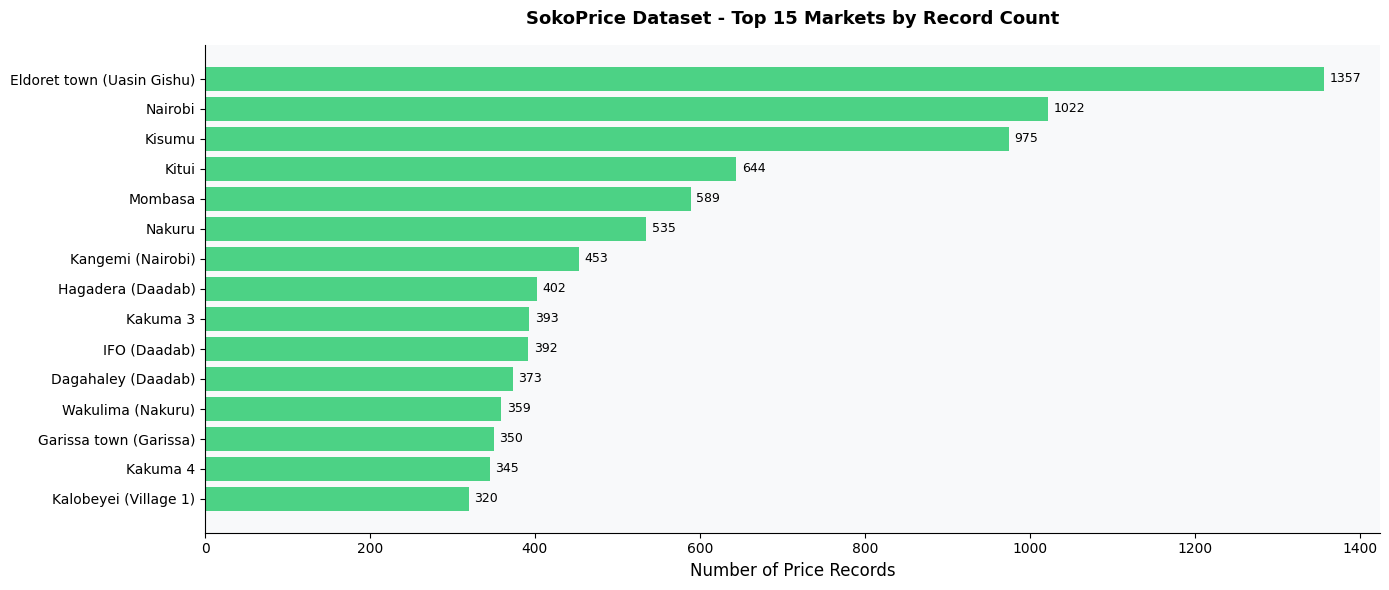

In [7]:
top_markets = df_target[MARKET_COL].value_counts().head(15)
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_markets.index[::-1], top_markets.values[::-1], color=SP_GREEN, alpha=0.85)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_xlabel('Number of Price Records', fontsize=12)
ax.set_title('SokoPrice Dataset - Top 15 Markets by Record Count', fontsize=13, fontweight='bold', pad=15)
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz1_markets.png', dpi=150, bbox_inches='tight'); plt.show()

Horizontal bar chart of the 15 markets with the most price records. Markets with more data points give the model a longer history to learn from, so this identifies which markets are reliable for training like the Eldoret town market, which is more suitable.

### Viz 2 - Price Distribution per Commodity (Box Plot)

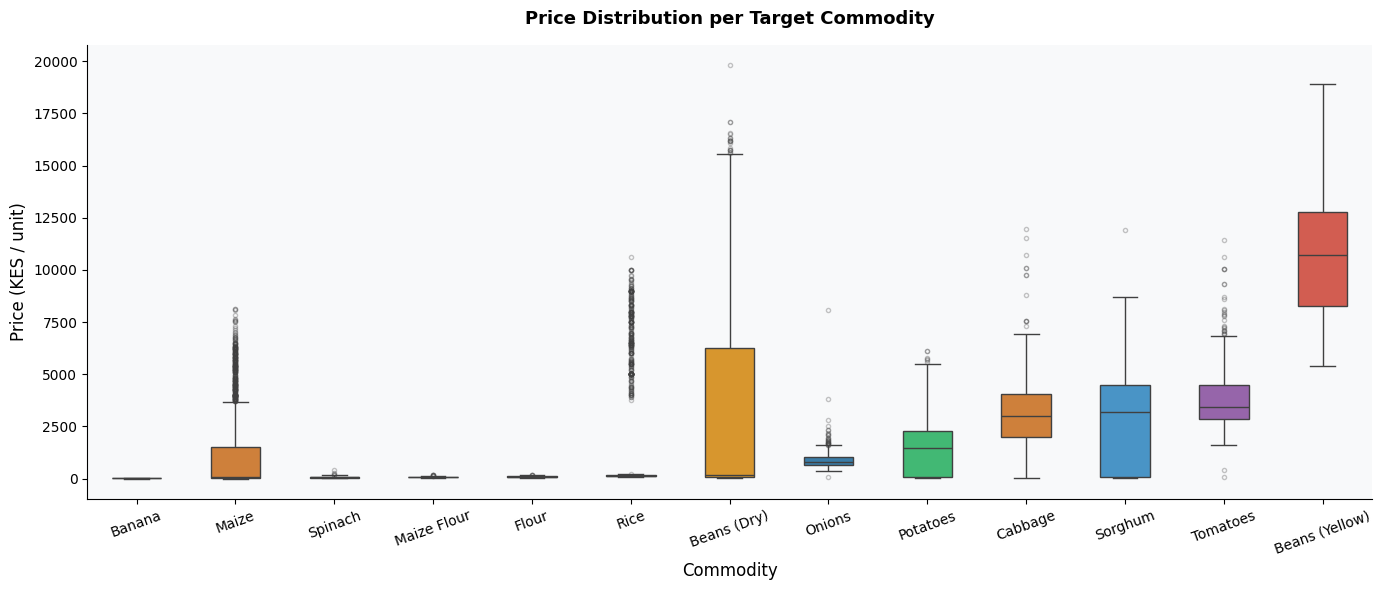

In [8]:
order = df_target.groupby('commodity_label')[PRICE_COL].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_target, x='commodity_label', y=PRICE_COL, order=order,
            palette=PALETTE[:len(order)], width=0.5,
            flierprops={'markersize': 3, 'alpha': 0.3}, ax=ax)
ax.set_title('Price Distribution per Target Commodity', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Commodity', fontsize=12); ax.set_ylabel('Price (KES / unit)', fontsize=12)
ax.tick_params(axis='x', rotation=20); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz2_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

This Box Plot shows the median, interquartile range, and outliers of prices for each commodity. The box height shows how much prices typically vary; long whiskers show frequent extreme price spikes.

### Viz 3 - Price Trends Over Time

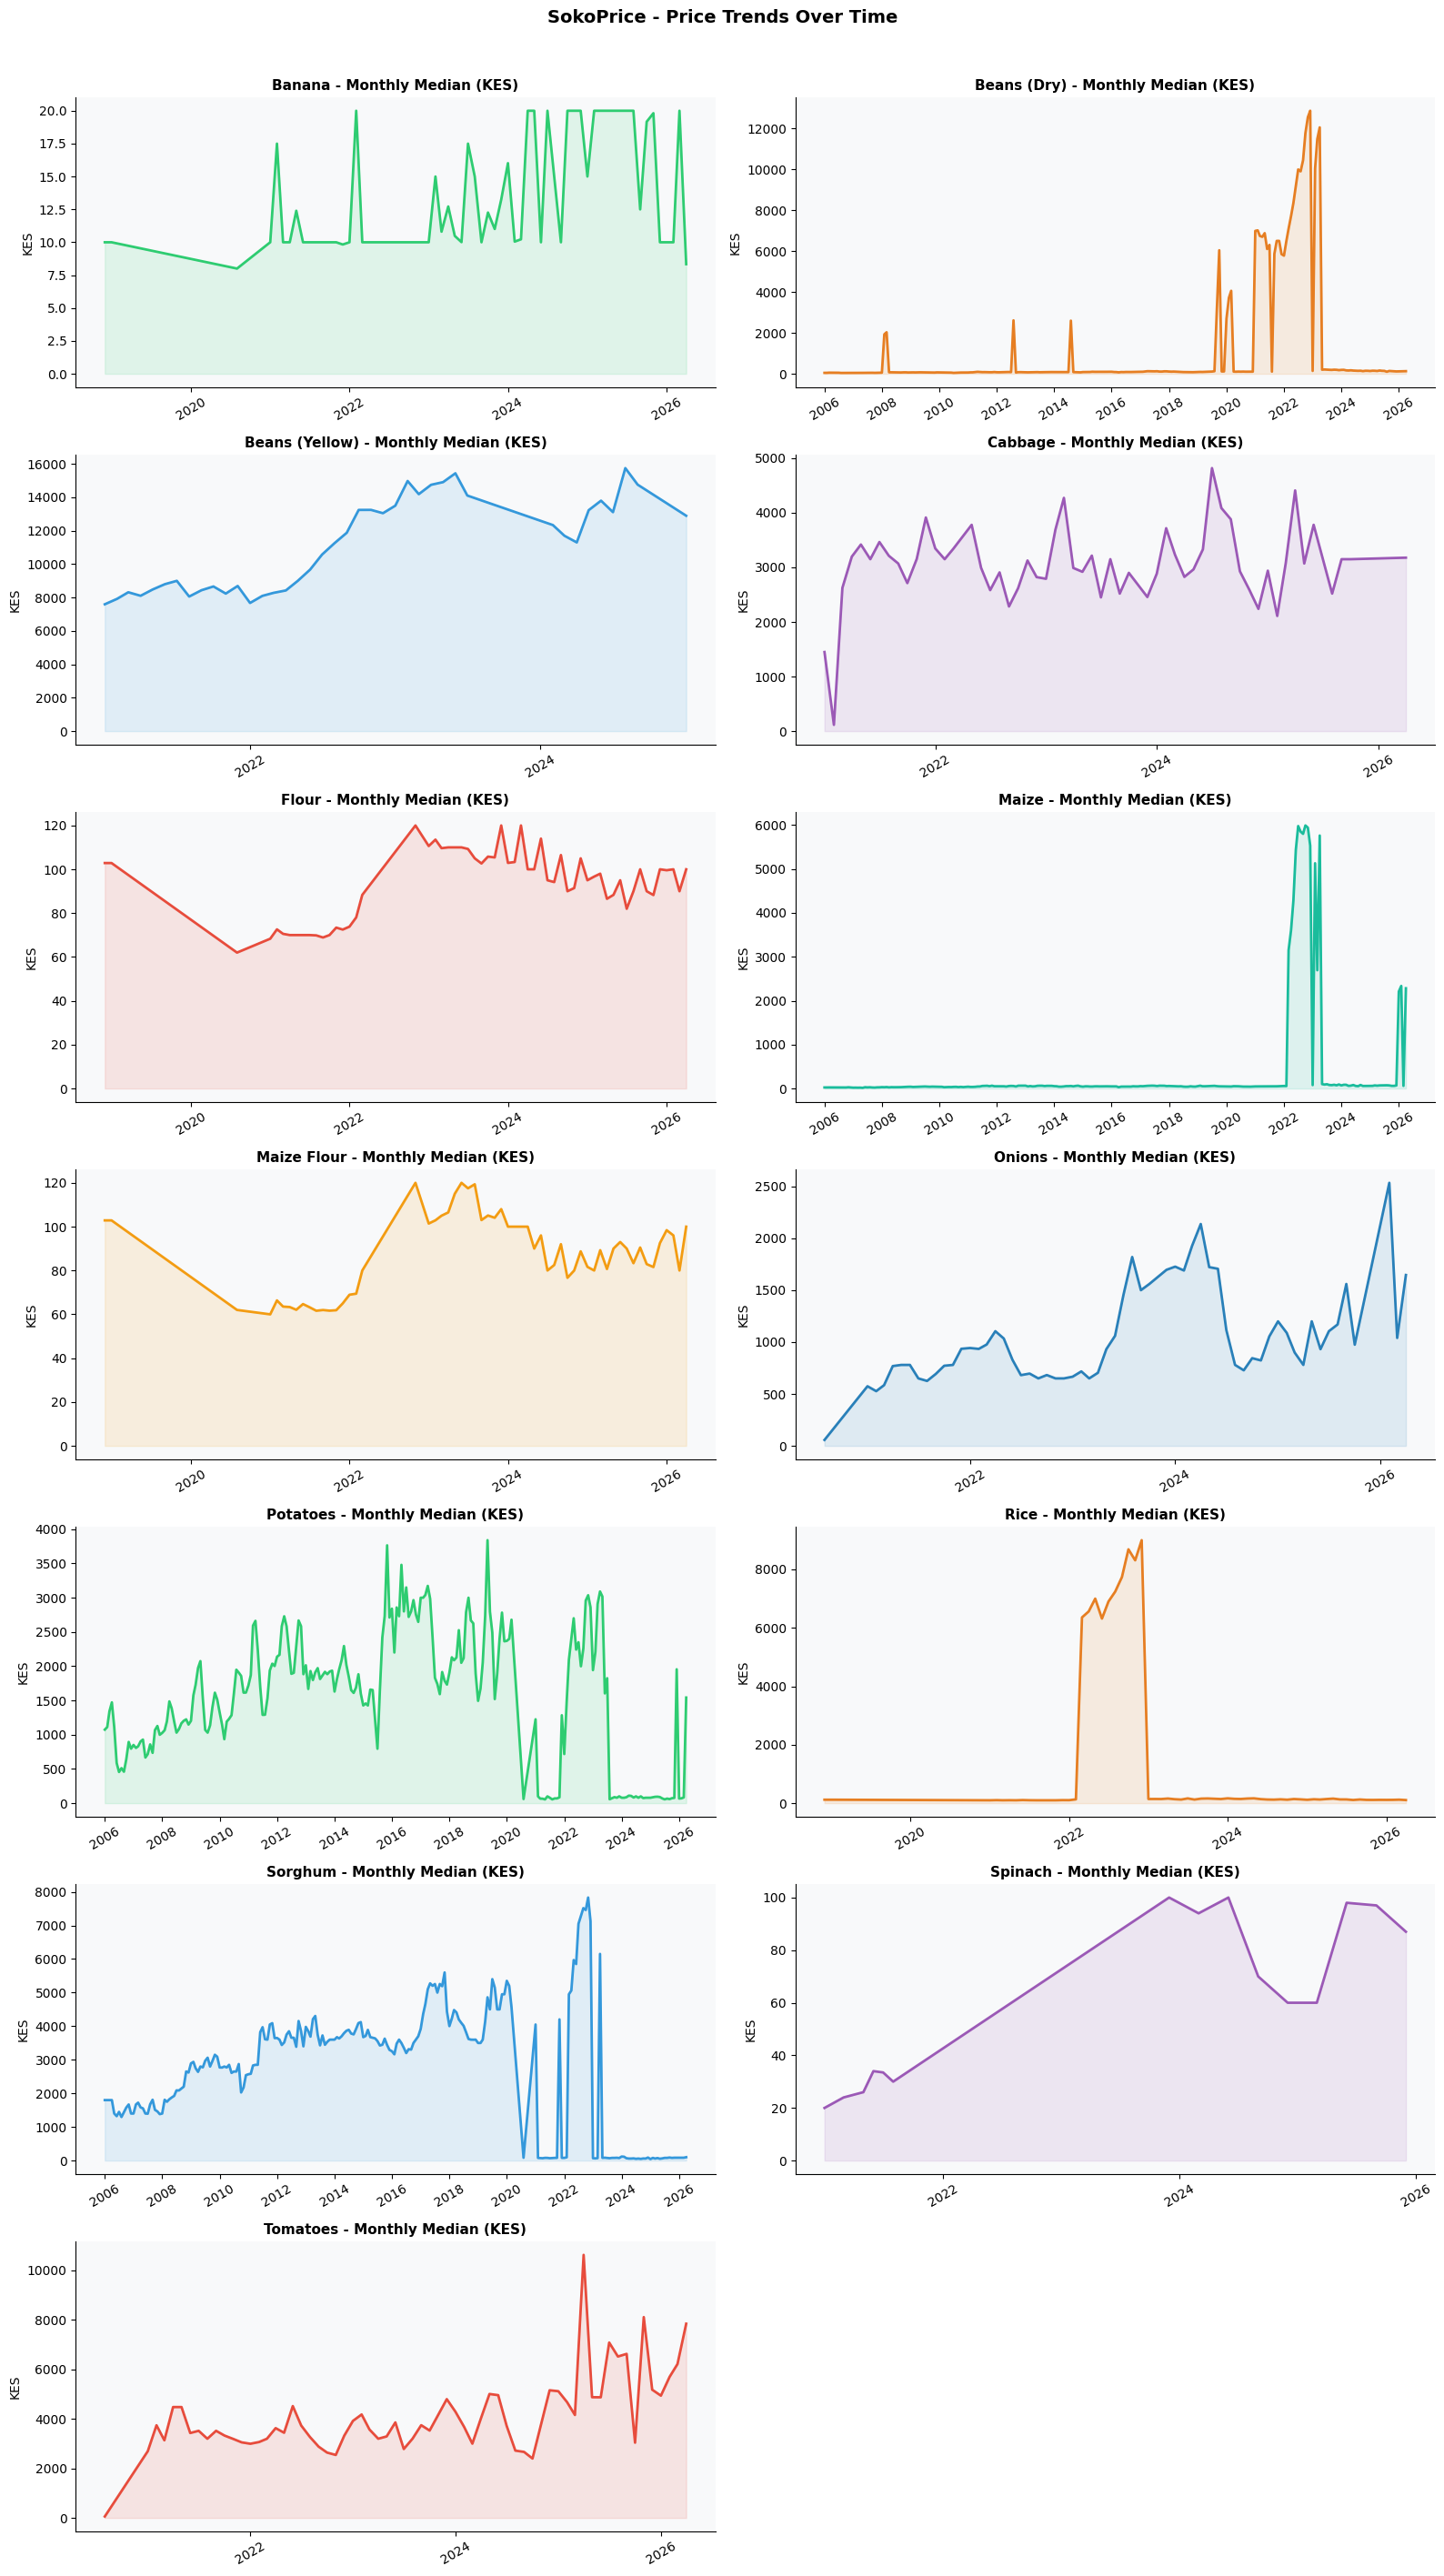

In [9]:
df_target['year_month'] = df_target[DATE_COL].dt.to_period('M')
monthly_avg = df_target.groupby(['year_month','commodity_label'])[PRICE_COL].median().reset_index()
monthly_avg['date'] = monthly_avg['year_month'].dt.to_timestamp()
commodities_list = sorted(monthly_avg['commodity_label'].unique())
ncols = 2; nrows = (len(commodities_list)+1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()
for i, comm in enumerate(commodities_list):
    data = monthly_avg[monthly_avg['commodity_label']==comm]
    color = PALETTE[i % len(PALETTE)]
    axes[i].plot(data['date'], data[PRICE_COL], color=color, linewidth=2)
    axes[i].fill_between(data['date'], data[PRICE_COL], alpha=0.12, color=color)
    axes[i].set_title(f'{comm} - Monthly Median (KES)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('KES')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].tick_params(axis='x', rotation=30); axes[i].set_facecolor('#F8F9FA')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('SokoPrice - Price Trends Over Time', fontsize=14, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz3_trends.png', dpi=150, bbox_inches='tight'); plt.show()

Line charts for each commodity, showing the monthly median price from 2010 to 2024. Upward slopes show long-term inflation; sharp spikes show shocks like droughts or supply disruptions.

### Viz 4 - Seasonal Price Index

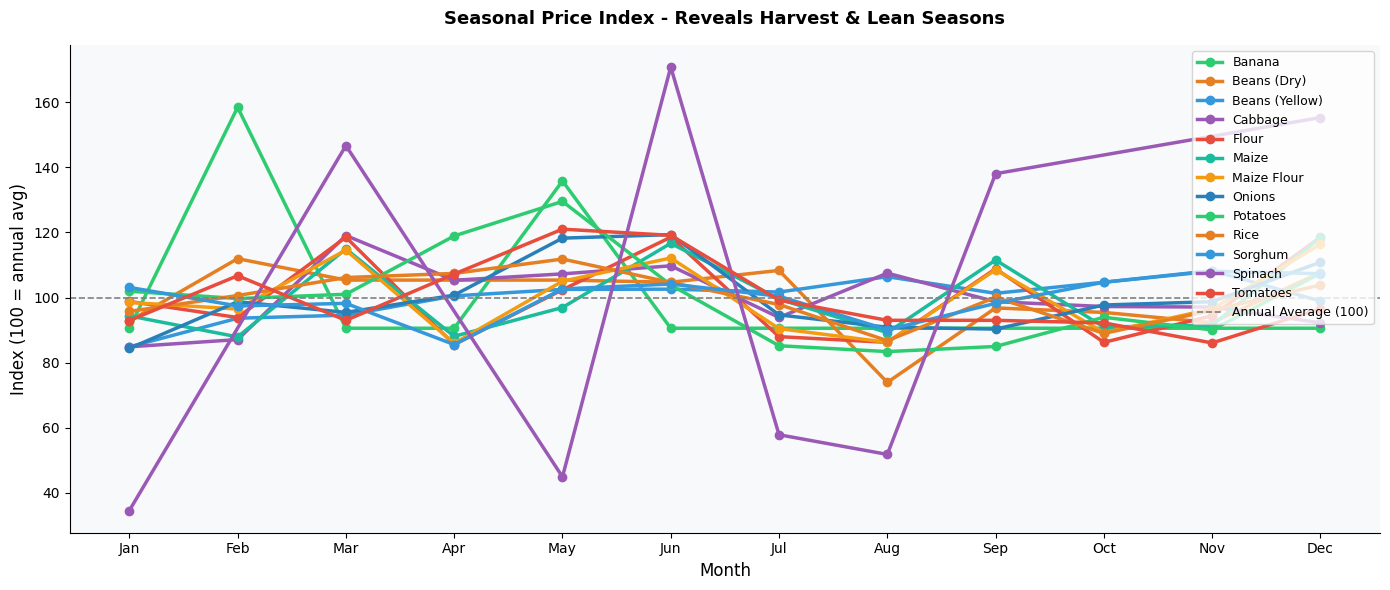

In [10]:
df_target['month'] = df_target[DATE_COL].dt.month
df_target['month_name'] = df_target[DATE_COL].dt.strftime('%b')
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = df_target.groupby(['month','month_name','commodity_label'])[PRICE_COL].median().reset_index()
seasonal['month_name'] = pd.Categorical(seasonal['month_name'], categories=MONTH_ORDER, ordered=True)
seasonal = seasonal.sort_values(['commodity_label','month'])
fig, ax = plt.subplots(figsize=(14, 6))
for i, comm in enumerate(sorted(seasonal['commodity_label'].unique())):
    data = seasonal[seasonal['commodity_label']==comm].copy()
    mp = data[PRICE_COL].mean()
    if mp == 0: continue
    data['idx'] = (data[PRICE_COL] / mp) * 100
    ax.plot(data['month_name'], data['idx'], marker='o', linewidth=2.5, label=comm, color=PALETTE[i % len(PALETTE)])
ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, label='Annual Average (100)')
ax.set_title('Seasonal Price Index - Reveals Harvest & Lean Seasons', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12); ax.set_ylabel('Index (100 = annual avg)', fontsize=12)
ax.legend(loc='upper right', fontsize=9); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz4_seasonal.png', dpi=150, bbox_inches='tight'); plt.show()

A line chart showing each commodity's price as a percentage of its yearly average, month by month. Values above 100 mean during that month is typically more expensive than average. These peaks mark lean seasons before harvest.

### Viz 5 - Price Volatility (Coefficient of Variation)

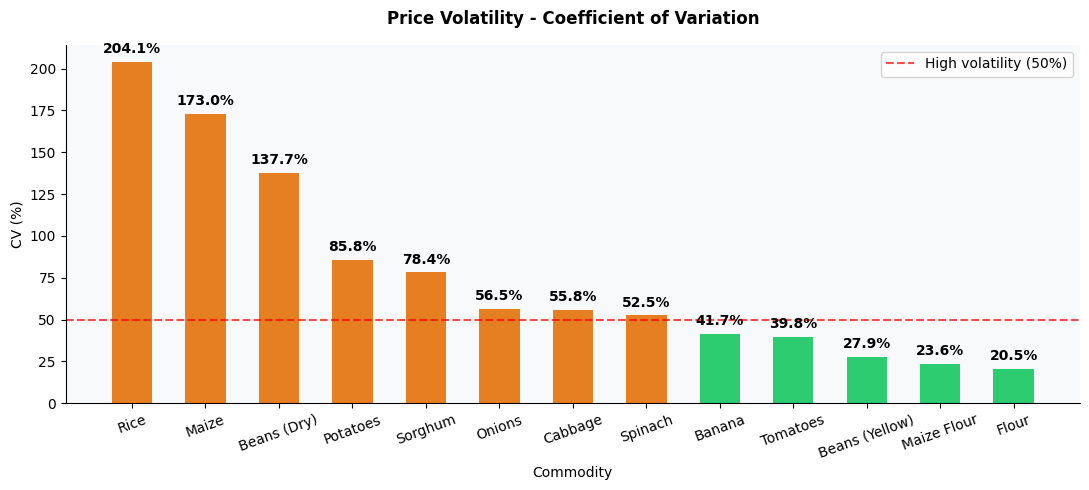

,commodity_label,mean_price,cv
9,Rice,1284.87,204.06
5,Maize,923.88,173.01
1,Beans (Dry),2929.32,137.70
8,Potatoes,1464.83,85.80
10,Sorghum,2852.66,78.38
7,Onions,909.35,56.54
3,Cabbage,3166.18,55.81
11,Spinach,82.87,52.45
0,Banana,13.55,41.66
12,Tomatoes,3816.35,39.84


In [11]:
volatility = (df_target.groupby('commodity_label')[PRICE_COL]
              .agg(mean_price='mean', std_price='std')
              .assign(cv=lambda x: (x['std_price']/x['mean_price'])*100)
              .reset_index().sort_values('cv', ascending=False))
fig, ax = plt.subplots(figsize=(11, 5))
c_vol = [SP_ACCENT if v > 50 else SP_GREEN for v in volatility['cv']]
bars  = ax.bar(volatility['commodity_label'], volatility['cv'], color=c_vol, width=0.55)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10, fontweight='bold')
ax.axhline(50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='High volatility (50%)')
ax.set_title('Price Volatility - Coefficient of Variation', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Commodity'); ax.set_ylabel('CV (%)'); ax.tick_params(axis='x', rotation=20)
ax.legend(); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz5_volatility.png', dpi=150, bbox_inches='tight'); plt.show()
display(volatility[['commodity_label','mean_price','cv']].round(2))

This Bar chart ranks commodities by how much their price fluctuates relative to their average price. Commodities above the 50% red line are the most unpredictable, meaning forecasting adds the most value for them.

### Viz 6 - Cross-Commodity Price Correlation

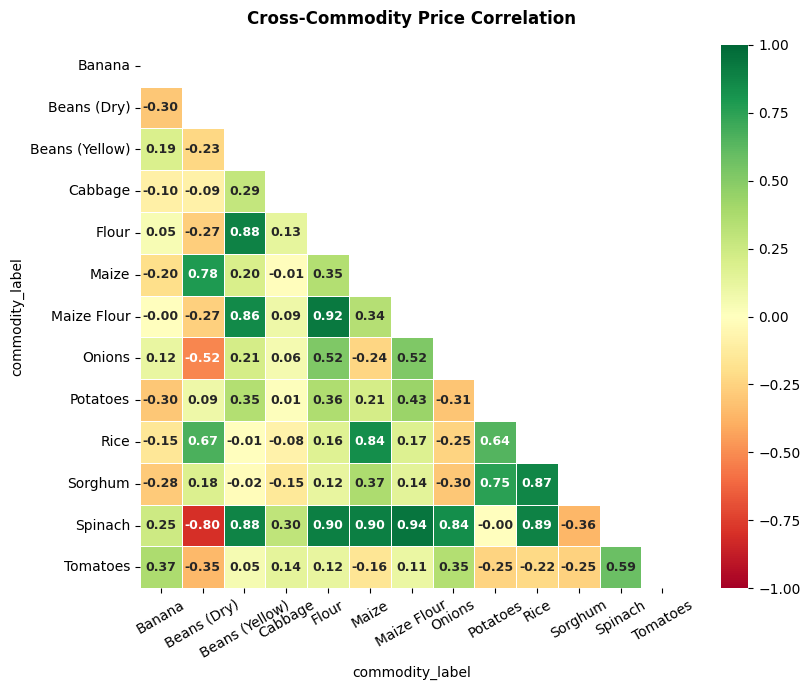

In [12]:
pivot = (df_target.groupby(['year_month','commodity_label'])[PRICE_COL]
         .median().unstack('commodity_label'))
pivot.index = pivot.index.to_timestamp()
pivot = pivot.dropna(how='all')
corr  = pivot.corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 9, 'weight': 'bold'}, ax=ax)
ax.set_title('Cross-Commodity Price Correlation', fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=30); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz6_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

Heatmap showing how closely each pair of commodities' prices move together, from -1 (opposite directions) to +1 (move identically). Strong positive values (green) indicate that two commodities respond to the same market pressures, such as fuel costs.

### Viz 7 - Inter-Market Price Comparison 

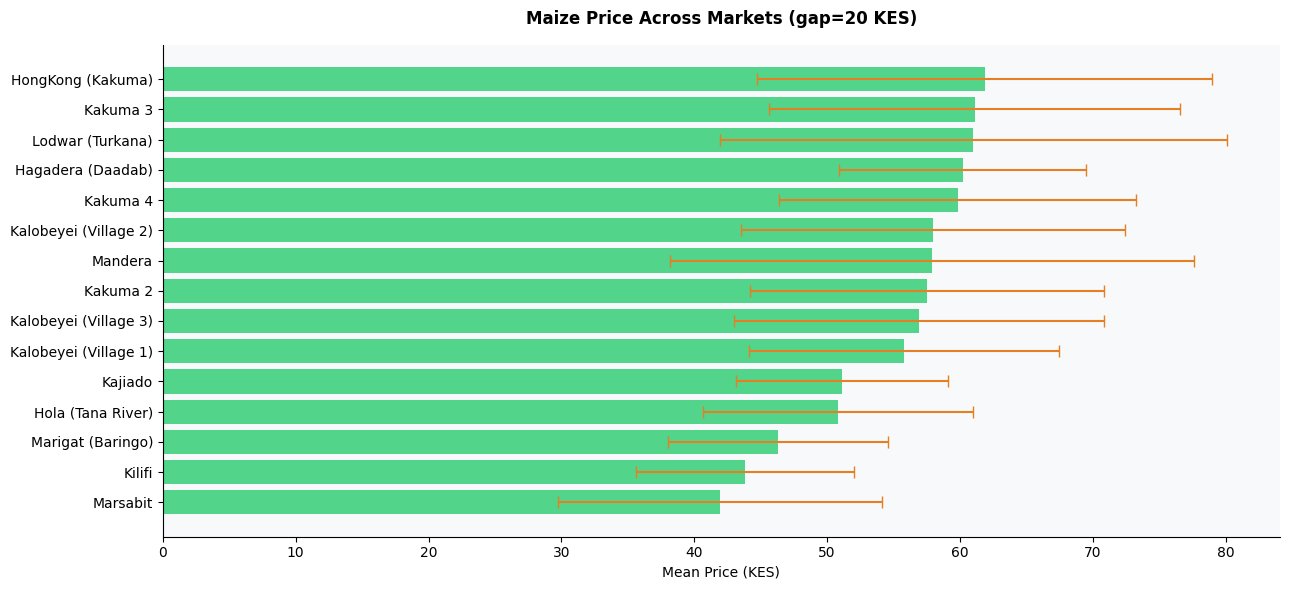

In [13]:
top_comm  = df_target['commodity_label'].value_counts().idxmax()
df_comm   = df_target[df_target['commodity_label']==top_comm].copy()
mkt_stats = (df_comm.groupby(MARKET_COL)[PRICE_COL]
             .agg(mean_price='mean', std_price='std', count='count').reset_index())
mkt_stats = mkt_stats[mkt_stats['count']>=15].sort_values('mean_price').head(15)
fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(mkt_stats[MARKET_COL], mkt_stats['mean_price'],
        xerr=mkt_stats['std_price'], color=SP_GREEN, alpha=0.82,
        error_kw={'ecolor': SP_ACCENT, 'capsize': 4})
gap = mkt_stats['mean_price'].max() - mkt_stats['mean_price'].min()
ax.set_title(f'{top_comm} Price Across Markets (gap={gap:.0f} KES)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Mean Price (KES)'); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz7_market_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

Horizontal bar chart comparing the average price of the most common commodity across 15 markets, with error bars showing price variability within each market. The size of the price gap between the cheapest and most expensive market shows how much a buyer could save by choosing the right market.


## Phase 4 - Data Preparation & Feature Engineering

In [14]:
df = df_target.copy()
df = df.sort_values([COMM_COL, MARKET_COL, DATE_COL]).reset_index(drop=True)

df['year']        = df[DATE_COL].dt.year
df['month']       = df[DATE_COL].dt.month
df['quarter']     = df[DATE_COL].dt.quarter
df['day_of_year'] = df[DATE_COL].dt.dayofyear
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

grp = df.groupby([COMM_COL, MARKET_COL])[PRICE_COL]
for lag in [1, 2, 3, 6]:
    df[f'price_lag_{lag}'] = grp.shift(lag)

for w in [3, 6, 12]:
    df[f'rolling_mean_{w}'] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    df[f'rolling_std_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std().fillna(0))

df['price_pct_change_1m'] = grp.pct_change(1).replace([np.inf, -np.inf], np.nan)
df['price_pct_change_3m'] = grp.pct_change(3).replace([np.inf, -np.inf], np.nan)

le_comm   = LabelEncoder()
le_market = LabelEncoder()
df['commodity_enc'] = le_comm.fit_transform(df['commodity_label'])
df['market_enc']    = le_market.fit_transform(df[MARKET_COL].astype(str))

FEATURE_COLS = [
    'year', 'month_sin', 'month_cos', 'quarter',
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_6',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
    'rolling_std_3', 'rolling_std_6',
    'price_pct_change_1m', 'price_pct_change_3m',
    'commodity_enc', 'market_enc'
]
TARGET_COL = PRICE_COL
df_ml = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
print(f'Feature engineering complete: {df_ml.shape[0]:,} rows x {len(FEATURE_COLS)} features')

Feature engineering complete: 11,824 rows x 17 features


### Viz 8 - Feature Correlation with Target Price

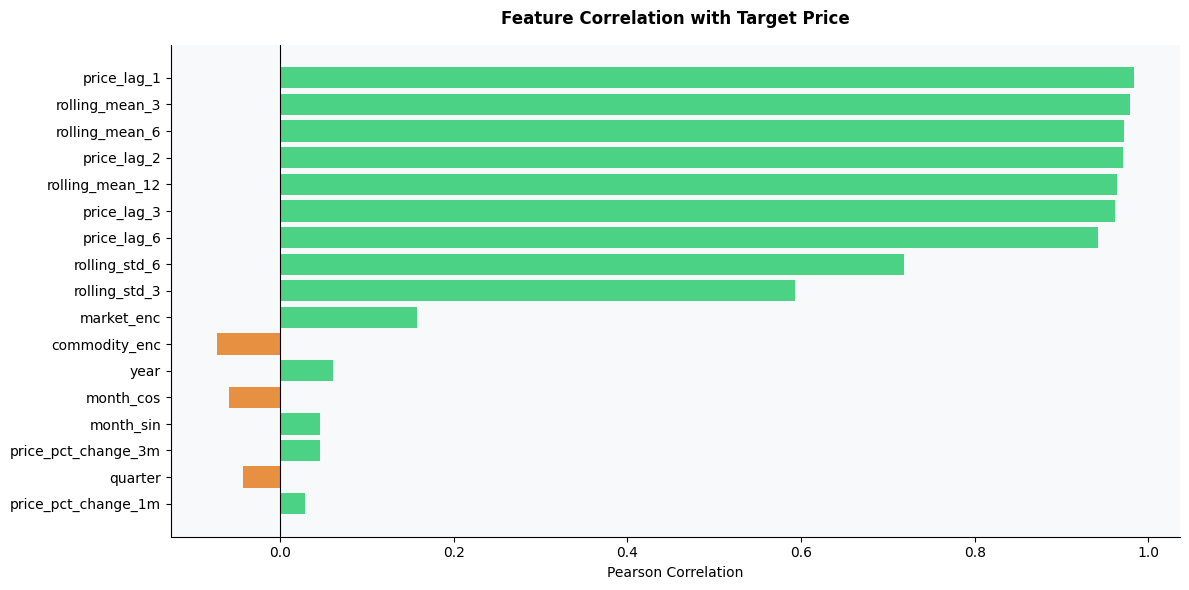

In [15]:
corr_target = (df_ml[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL]
               .drop(TARGET_COL).sort_values(key=abs, ascending=False))
fig, ax = plt.subplots(figsize=(12, 6))
colors_feat = [SP_GREEN if v > 0 else SP_ACCENT for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_feat[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target Price', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Pearson Correlation'); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz8_feature_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

This Bar chart ranks all 17 engineered features by how strongly they correlate with the actual price. Bars near the top (usually price lags and rolling averages) are the features the model relies on most.

In [16]:
# Temporal train/test split
df_ml = df_ml.sort_values(DATE_COL).reset_index(drop=True)
split_idx = int(len(df_ml) * 0.8)
train_df = df_ml.iloc[:split_idx]; test_df = df_ml.iloc[split_idx:]
X_train = train_df[FEATURE_COLS].values; y_train = train_df[TARGET_COL].values
X_test  = test_df[FEATURE_COLS].values;  y_test  = test_df[TARGET_COL].values
scaler_X = MinMaxScaler(); scaler_y = MinMaxScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1,1)).ravel()
print(f'Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples')
print(f'Split: 80% train / 20% test (temporal - no data leakage)')

Train: 9,459 samples | Test: 2,365 samples
Split: 80% train / 20% test (temporal - no data leakage)


---
## Phase 5 - Model Architecture & Training

### Architecture Overview

| Model | Type | Key Hyperparameters | Activation | Optimizer |
|---|---|---|---|---|
| **Linear Regression** | Parametric | 17 coefficients + intercept | Linear (identity) | OLS closed-form |
| **Random Forest** | Ensemble (bagging) | n_estimators=300, max_features=sqrt | N/A (tree splits) | Bootstrap aggregation |
| **XGBoost** | Ensemble (boosting) | n_estimators=500, lr=0.05, max_depth=6 | N/A (tree splits) | Gradient descent |
| **SVR** | Kernel method | C=100, gamma=0.01, epsilon=0.01 | RBF kernel | SMO algorithm |
| **LSTM** | Deep learning | LSTM(128→64), Dense(32→1) | ReLU | Adam (lr=0.001) |

In [17]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'  MAE  : {mae:.3f} KES')
    print(f'  RMSE : {rmse:.3f} KES')
    print(f'  R2   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'Model': name, 'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R2': round(r2,4), 'MAPE (%)': round(mape,2)}

results = []; predictions = {}
print('Evaluation helper ready')

Evaluation helper ready


### Model 1 - Linear Regression
**Architecture:** Fits `y = Xb + e` by minimising the sum of squared residuals (OLS).
No hidden layers. Serves as an interpretable baseline.
- Input: 17 scaled features
- Parameters: 17 coefficients + 1 intercept
- Optimisation: Ordinary Least Squares (closed-form)

In [18]:
# Training Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train_sc)
y_pred_lr = scaler_y.inverse_transform(lr.predict(X_test_sc).reshape(-1,1)).ravel()
y_pred_lr = np.clip(y_pred_lr, 0, None)
print('\nLinear Regression - Performance Metrics:')
res = evaluate('Linear Regression', y_test, y_pred_lr)
results.append(res); predictions['Linear Regression'] = y_pred_lr
joblib.dump(lr, 'model_lr.pkl'); joblib.dump(scaler_X, 'scaler_X.pkl'); joblib.dump(scaler_y, 'scaler_y.pkl')
print('Saved: model_lr.pkl')


Linear Regression - Performance Metrics:
  MAE  : 172.620 KES
  RMSE : 558.281 KES
  R2   : 0.9485
  MAPE : 80.87%
Saved: model_lr.pkl


### Model 2 - Random Forest
**Architecture:** Ensemble of 300 decision trees trained on bootstrap samples.
Each split uses sqrt(features) random features. Final prediction = mean of all trees.
- n_estimators: 300 | max_features: sqrt | min_samples_split: 5
- Optimisation: Bootstrap aggregation (bagging) - reduces variance

In [19]:
# Training Random Forest (300 trees)
rf = RandomForestRegressor(n_estimators=300, max_depth=None,
    min_samples_split=5, min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('\nRandom Forest - Performance Metrics:')
res = evaluate('Random Forest', y_test, y_pred_rf)
results.append(res); predictions['Random Forest'] = y_pred_rf
joblib.dump(rf, 'model_rf.pkl')
print('Saved: model_rf.pkl')


Random Forest - Performance Metrics:
  MAE  : 79.965 KES
  RMSE : 385.172 KES
  R2   : 0.9755
  MAPE : 14.24%
Saved: model_rf.pkl


### Model 3 - XGBoost
**Architecture:** Sequential gradient boosting ensemble. Each tree corrects residuals of previous.
- n_estimators: 500 | learning_rate: 0.05 | max_depth: 6
- Regularisation: L1 alpha=0.1, L2 lambda=1.0
- Optimisation: Gradient descent on squared error loss

In [20]:
# Training XGBoost (500 estimators)
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
print('\nXGBoost - Performance Metrics:')
res = evaluate('XGBoost', y_test, y_pred_xgb)
results.append(res); predictions['XGBoost'] = y_pred_xgb
joblib.dump(xgb, 'model_xgb.pkl')
print('Saved: model_xgb.pkl')


XGBoost - Performance Metrics:
  MAE  : 47.334 KES
  RMSE : 212.692 KES
  R2   : 0.9925
  MAPE : 14.23%
Saved: model_xgb.pkl


### Model 4 - SVR (Support Vector Regression)
**Architecture:** Maps features into high-dimensional space via RBF kernel, fits hyperplane
within an epsilon-insensitive tube.
- Kernel: RBF - K(x,x') = exp(-gamma * ||x-x'||^2)
- C: 100 | gamma: 0.01 | epsilon: 0.01
- Optimisation: SMO (Sequential Minimal Optimisation)

In [21]:
# Training SVR (RBF kernel)
svr = SVR(kernel='rbf', C=100, gamma=0.01, epsilon=0.01)
svr.fit(X_train_sc, y_train_sc)
y_pred_svr = scaler_y.inverse_transform(svr.predict(X_test_sc).reshape(-1,1)).ravel()
y_pred_svr = np.clip(y_pred_svr, 0, None)
print('\nSVR - Performance Metrics:')
res = evaluate('SVR (RBF)', y_test, y_pred_svr)
results.append(res); predictions['SVR (RBF)'] = y_pred_svr
joblib.dump(svr, 'model_svr.pkl')
print('Saved: model_svr.pkl')


SVR - Performance Metrics:
  MAE  : 181.912 KES
  RMSE : 521.285 KES
  R2   : 0.9551
  MAPE : 94.48%
Saved: model_svr.pkl


### Model 5 - LSTM Neural Network
**Architecture:**
```
Input  (12 timesteps x 17 features)
  LSTM(128, return_sequences=True)   <- long-range dependencies
  Dropout(0.2)
  BatchNormalization()
  LSTM(64, return_sequences=False)   <- distil temporal patterns
  Dropout(0.2)
  Dense(32, activation='relu')       <- non-linear price mapping
  Dense(1)                           <- predicted price (KES)

Loss:      Huber  (robust to outliers)
Optimizer: Adam(lr=0.001, beta_1=0.9, beta_2=0.999)
Callbacks: EarlyStopping(patience=15) + ReduceLROnPlateau(patience=7)
```

In [22]:
SEQ_LEN = 6
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq_tr, y_seq_tr = make_sequences(X_train_sc, y_train_sc, SEQ_LEN)
X_seq_te, y_seq_te = make_sequences(X_test_sc,  y_test_sc,  SEQ_LEN)
print(f'LSTM shapes - Train: {X_seq_tr.shape} | Test: {X_seq_te.shape}')

n_feat = X_seq_tr.shape[2]
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, n_feat)),
    Dropout(0.3),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1)
], name='SokoPrice_LSTM')
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
lstm_model.summary()

LSTM shapes - Train: (9453, 6, 17) | Test: (2359, 6, 17)


I0000 00:00:1781397454.183268    1204 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781397454.188546    1204 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SokoPrice_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,081 (133.13 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100


I0000 00:00:1781397458.188732    1289 cuda_dnn.cc:529] Loaded cuDNN version 91002


126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0181 - mae: 0.1442 - val_loss: 0.0310 - val_mae: 0.1490 - learning_rate: 0.0010
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0114 - mae: 0.1178 - val_loss: 0.0287 - val_mae: 0.1541 - learning_rate: 0.0010
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0106 - mae: 0.1139 - val_loss: 0.0274 - val_mae: 0.1596 - learning_rate: 0.0010
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0103 - mae: 0.1129 - val_loss: 0.0268 - val_mae: 0.1657 - learning_rate: 0.0010
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0102 - mae: 0.1124 - val_loss: 0.0267 - val_mae: 0.1650 - learning_rate: 0.0010
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0100 - mae: 0.1121 - val_loss: 0.0267 - val_mae: 0.1683 - learning_rate: 0.0010
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0099 - mae: 0.1113 - val_loss: 0.0268 - val_mae: 0.1692 - learning_rate: 0.0010
Epoch 8/10

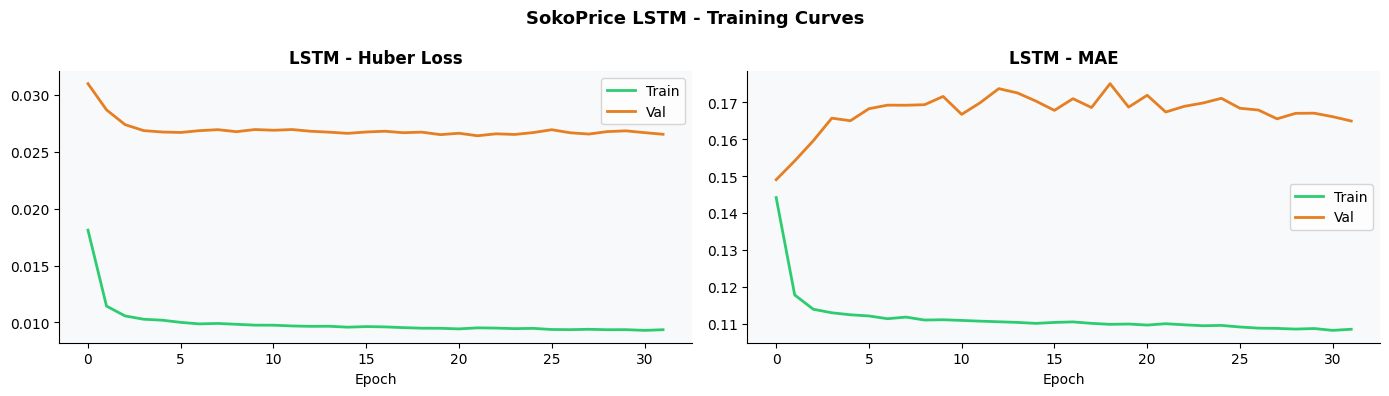

Stopped at epoch 32


In [23]:
# Training LSTM
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-5, verbose=0)
]
history = lstm_model.fit(X_seq_tr, y_seq_tr, validation_split=0.15,
    epochs=100, batch_size=64, callbacks=callbacks, verbose=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train', color=SP_GREEN,  lw=2)
axes[0].plot(history.history['val_loss'], label='Val',   color=SP_ACCENT, lw=2)
axes[0].set_title('LSTM - Huber Loss', fontweight='bold'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')
axes[1].plot(history.history['mae'],     label='Train', color=SP_GREEN,  lw=2)
axes[1].plot(history.history['val_mae'], label='Val',   color=SP_ACCENT, lw=2)
axes[1].set_title('LSTM - MAE', fontweight='bold'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')
fig.suptitle('SokoPrice LSTM - Training Curves', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz_lstm_curves.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Stopped at epoch {len(history.history["loss"])}')

The line charts track the LSTM's loss and MAE on the training and validation sets across epochs. The line charts show that the LSTM model's training loss and error dropped quickly and flattened out. However, the validation loss and error remained significantly higher with noticeable fluctuations. This indicates that the model began to overfit.

In [24]:
y_pred_lstm_sc = lstm_model.predict(X_seq_te, verbose=0).ravel()
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_sc.reshape(-1,1)).ravel()
y_pred_lstm = np.clip(y_pred_lstm, 0, None)
y_test_lstm = scaler_y.inverse_transform(y_seq_te.reshape(-1,1)).ravel()
print(len(y_test_lstm), len(y_pred_lstm))

res = evaluate('LSTM', y_test_lstm, y_pred_lstm)
results.append(res)
predictions['LSTM'] = (y_test_lstm, y_pred_lstm)
lstm_model.save('model_lstm.keras')
print('Saved: model_lstm.keras')

2359 2359
  MAE  : 2104.138 KES
  RMSE : 2707.327 KES
  R2   : -0.2117
  MAPE : 2715.74%
Saved: model_lstm.keras


## Model 6 - GRU (Gated Recurrent Unit)
 **Architecture:**
 Input  (12 timesteps x 17 features)
   GRU(128, return_sequences=True)   <- captures sequential price patterns
   Dropout(0.2)
   BatchNormalization()
   GRU(64, return_sequences=False)   <- distils temporal signal
   Dropout(0.2)
   Dense(32, activation='relu')
   Dense(1)                          <- predicted price (KES)

 Loss    : Huber (robust to outliers)
 Optimizer: Adam(lr=0.001)
 GRU is faster than LSTM with comparable accuracy,
 uses Reset Gate and Update Gate instead of LSTM's 3-gate system

In [25]:
from tensorflow.keras.layers import GRU

SEQ_LEN = 12  # reuse same sequences as LSTM
# X_seq_tr, y_seq_tr, X_seq_te, y_seq_te already built in LSTM cell

n_feat = X_seq_tr.shape[2]
gru_model = Sequential([
    GRU(128, return_sequences=True, input_shape=(SEQ_LEN, n_feat)),
    Dropout(0.2),
    BatchNormalization(),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
], name='SokoPrice_GRU')

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0209 - mae: 0.1538 - val_loss: 0.0271 - val_mae: 0.1575 - learning_rate: 0.0010
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0117 - mae: 0.1186 - val_loss: 0.0260 - val_mae: 0.1647 - learning_rate: 0.0010
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0105 - mae: 0.1134 - val_loss: 0.0263 - val_mae: 0.1702 - learning_rate: 0.0010
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0101 - mae: 0.1116 - val_loss: 0.0270 - val_mae: 0.1752 - learning_rate: 0.0010
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0098 - mae: 0.1108 - val_loss: 0.0278 - val_mae: 0.1806 - learning_rate: 0.0010
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0098 - mae: 0.1106 - val_loss: 0.0273 - val_mae: 0.1756 - learning_rate: 0.0010
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0097 - mae: 0.1105 - val_loss: 0.0276 - val_mae: 0.1795 - learning_rate: 0.001

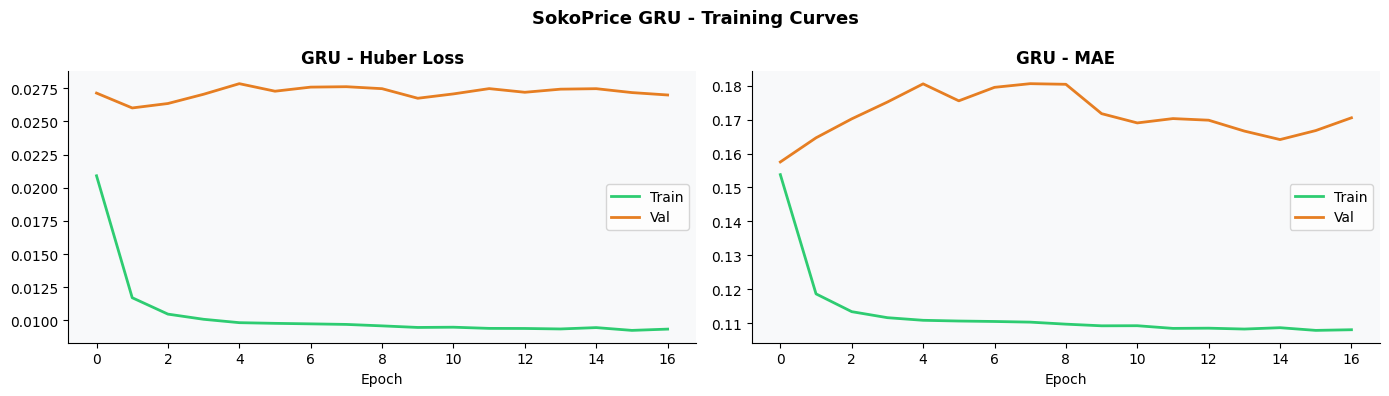

Stopped at epoch 17

GRU - Performance Metrics:
  MAE  : 2100.442 KES
  RMSE : 2671.393 KES
  R2   : -0.1798
  MAPE : 2724.03%
Saved: model_gru.keras


In [26]:
# GRU Training 
gru_callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-5, verbose=0)
]
gru_history = gru_model.fit(
    X_seq_tr, y_seq_tr,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=gru_callbacks,
    verbose=1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(gru_history.history['loss'],     label='Train', color=SP_GREEN,  lw=2)
axes[0].plot(gru_history.history['val_loss'], label='Val',   color=SP_ACCENT, lw=2)
axes[0].set_title('GRU - Huber Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].set_facecolor('#F8F9FA')

axes[1].plot(gru_history.history['mae'],     label='Train', color=SP_GREEN,  lw=2)
axes[1].plot(gru_history.history['val_mae'], label='Val',   color=SP_ACCENT, lw=2)
axes[1].set_title('GRU - MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].set_facecolor('#F8F9FA')

fig.suptitle('SokoPrice GRU - Training Curves', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('viz_gru_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Stopped at epoch {len(gru_history.history["loss"])}')

# Evaluate
y_pred_gru_sc = gru_model.predict(X_seq_te, verbose=0).ravel()
y_pred_gru    = scaler_y.inverse_transform(y_pred_gru_sc.reshape(-1,1)).ravel()
y_pred_gru    = np.clip(y_pred_gru, 0, None)

print('\nGRU - Performance Metrics:')
res = evaluate('GRU', y_test_lstm, y_pred_gru) 
results.append(res)
predictions['GRU'] = (y_test_lstm, y_pred_gru)

gru_model.save('model_gru.keras')
print('Saved: model_gru.keras')

The training curves show that the GRU model's training loss and error quickly decrease and flatten, while the validation metrics remain high and diverge. This gap, combined with the sharp upward spikes in validation error, highlights that the model is overfitting to the training data.

## Model 7 - LightGBM 
**Architecture:** 
 Gradient boosting framework using histogram-based tree learning.
 Faster than XGBoost on large datasets, uses leaf-wise tree growth
 Instead of level-wise, which finds better splits.

**Key hyperparameters:**
   n_estimators   : 500
   learning_rate  : 0.05
   max_depth     : -1 (no limit, controlled by num_leaves)
   num_leaves    : 63  (main complexity parameter)
   min_child_samples: 20
   subsample      : 0.8 (row sampling per tree)
   colsample_bytree: 0.8 (feature sampling per tree)
   reg_alpha      : 0.1 (L1), reg_lambda: 1.0 (L2)
 Optimisation: Gradient descent on squared error loss (leaf-wise)

LightGBM version: 4.6.0
Training LightGBM...

LightGBM - Performance Metrics:
  MAE  : 35.602 KES
  RMSE : 224.982 KES
  R2   : 0.9916
  MAPE : 9.03%
Saved: model_lgbm.pkl


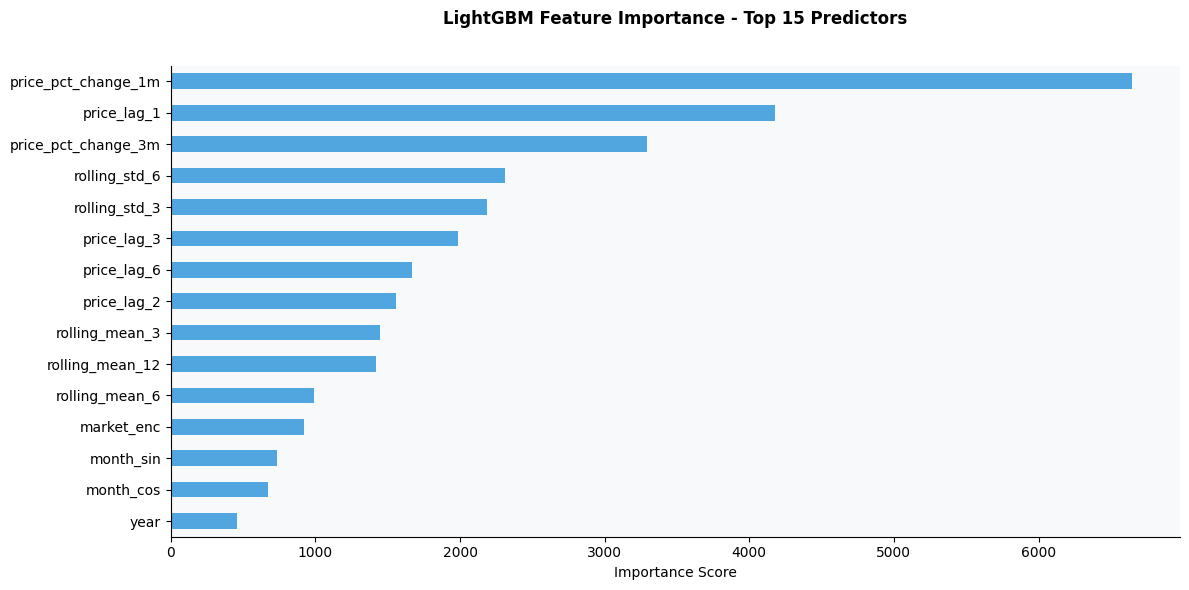

In [35]:
!pip install lightgbm -q

import lightgbm as lgb
print(f'LightGBM version: {lgb.__version__}')

lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

print('Training LightGBM...')
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

y_pred_lgbm = lgbm.predict(X_test)

print('\nLightGBM - Performance Metrics:')
res = evaluate('LightGBM', y_test, y_pred_lgbm)
results.append(res)
predictions['LightGBM'] = y_pred_lgbm

joblib.dump(lgbm, 'model_lgbm.pkl')
print('Saved: model_lgbm.pkl')

# Feature importance
fi_lgbm = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
fi_lgbm.head(15)[::-1].plot(kind='barh', ax=ax, color='#3498DB', alpha=0.85)
ax.set_title(
    'LightGBM Feature Importance - Top 15 Predictors\n',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Importance Score'); ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('viz_lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 6 - Evaluation & Model Comparison

In [28]:
results_df = pd.DataFrame(results).sort_values('MAPE (%)')
best = results_df.iloc[0]
print('=' * 62)
print('       SOKOPRICE - MODEL COMPARISON TABLE')
print('=' * 62)
print(results_df.to_string(index=False))
print('=' * 62)
print(f'\nBest Model : {best["Model"]}')
print(f'  MAPE     : {best["MAPE (%)"]:.2f}%  (primary metric)')
print(f'  R2       : {best["R2"]:.4f}  (variance explained)')
print(f'  MAE      : {best["MAE"]:.3f} KES  (average prediction error)')
print(f'  RMSE     : {best["RMSE"]:.3f} KES  (penalised large errors)')
lr_res = results_df[results_df['Model']=='Linear Regression'].iloc[0]
print(f'\nMAPE improvement over baseline: {lr_res["MAPE (%)"]-best["MAPE (%)"]:.2f}%')

       SOKOPRICE - MODEL COMPARISON TABLE
            Model      MAE     RMSE      R2  MAPE (%)
         LightGBM   35.602  224.982  0.9916      9.03
          XGBoost   47.334  212.692  0.9925     14.23
    Random Forest   79.965  385.172  0.9755     14.24
Linear Regression  172.620  558.281  0.9485     80.87
        SVR (RBF)  181.912  521.285  0.9551     94.48
             LSTM 2104.138 2707.327 -0.2117   2715.74
              GRU 2100.442 2671.393 -0.1798   2724.03

Best Model : LightGBM
  MAPE     : 9.03%  (primary metric)
  R2       : 0.9916  (variance explained)
  MAE      : 35.602 KES  (average prediction error)
  RMSE     : 224.982 KES  (penalised large errors)

MAPE improvement over baseline: 71.84%


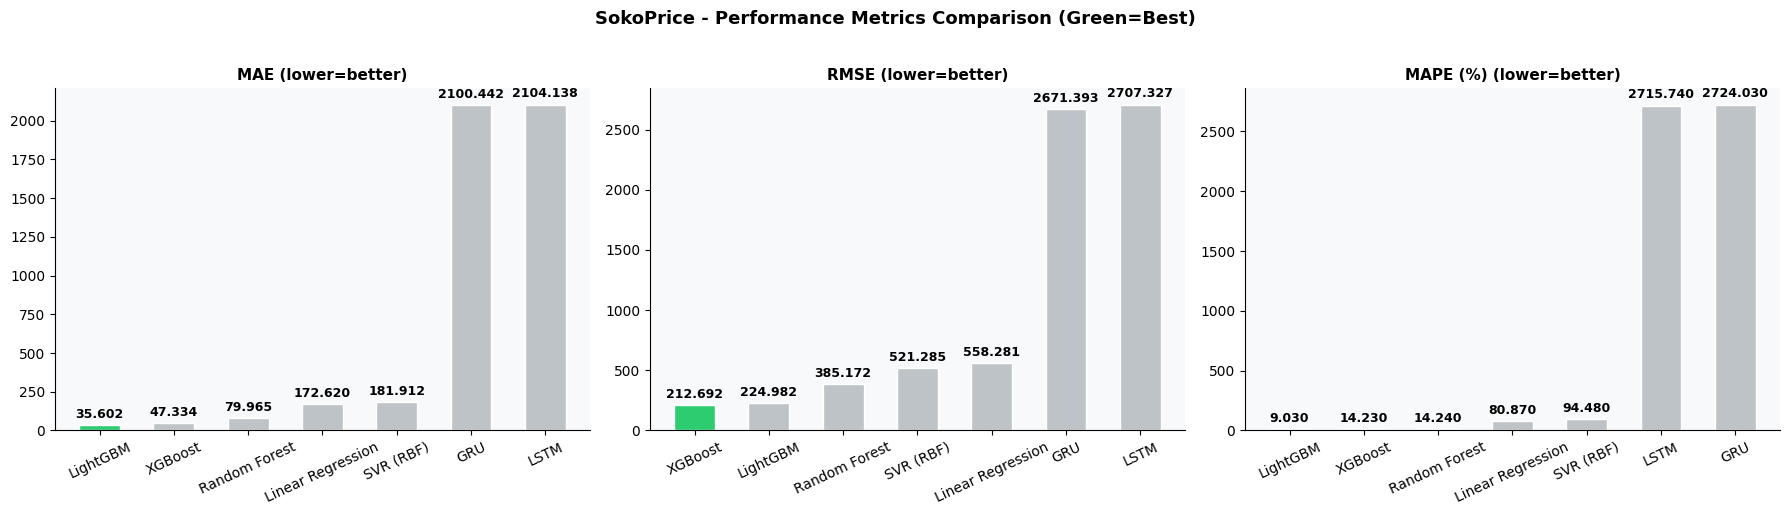

In [43]:
# Viz 9: Metric comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE (%)']):
    df_s = results_df.sort_values(metric)
    c_m  = [SP_GREEN if j==0 else '#BDC3C7' for j in range(len(df_s))]
    bars = axes[i].bar(df_s['Model'], df_s[metric], color=c_m, edgecolor='white', width=0.55)
    axes[i].bar_label(bars, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')
    axes[i].set_title(f'{metric} (lower=better)', fontweight='bold', fontsize=11)
    axes[i].tick_params(axis='x', rotation=25); axes[i].set_facecolor('#F8F9FA')
fig.suptitle('SokoPrice - Performance Metrics Comparison (Green=Best)', fontsize=13, fontweight='bold', y=1.02)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz9_Performance metrics comparison.png', dpi=150, bbox_inches='tight'); plt.show()

The bar charts compare different models across MAE, RMSE, and MAPE metrics. The lower scores mean better accuracy. Tree-based models like LightGBM and XGBoost achieve the best performance with the lowest errors. The deep learning GRU and LSTM models perform the worst, showing massive errors compared to all other methods.

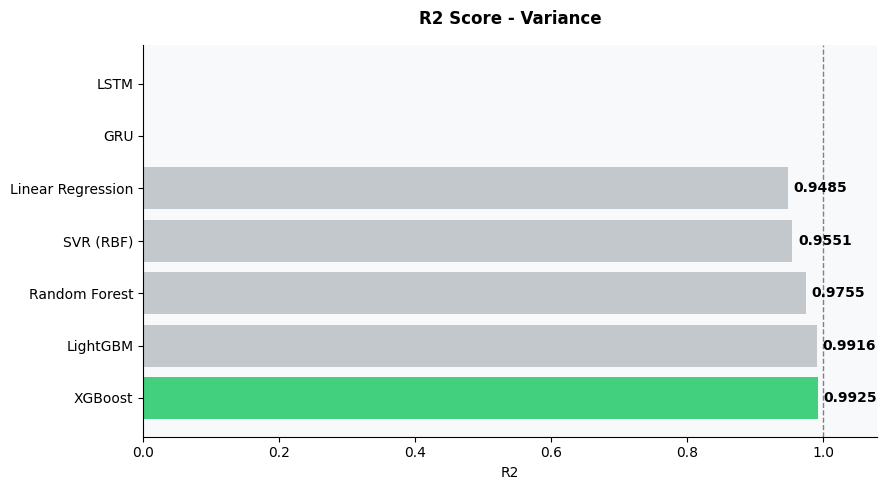

In [30]:
# Viz 10: R2
fig, ax = plt.subplots(figsize=(9, 5))
df_r2 = results_df.sort_values('R2', ascending=False)
c_r2  = [SP_GREEN if j==0 else '#BDC3C7' for j in range(len(df_r2))]
bars  = ax.barh(df_r2['Model'], df_r2['R2'], color=c_r2, alpha=0.9)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')
ax.set_xlim(0, 1.08); ax.axvline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_title('R2 Score - Variance', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('R2'); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz10_r2.png', dpi=150, bbox_inches='tight'); plt.show()

This bar chart compares the R2 scores of the models, where a score closer to 1.0 indicates better variance explanation. XGBoost and LightGBM perform the best, both achieving high accuracy above 0.99. The deep learning models GRU and LSTM fail, showing no positive R2 scores.

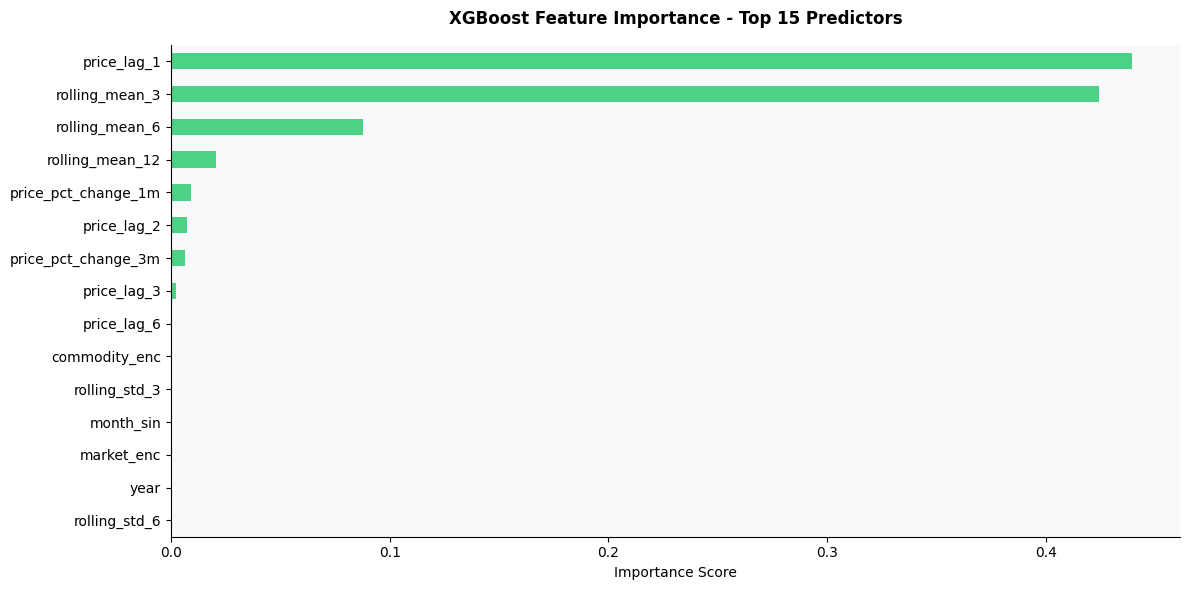

In [31]:
# Viz 11: Feature importance
fi = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
fi.head(15)[::-1].plot(kind='barh', ax=ax, color=SP_GREEN, alpha=0.85)
ax.set_title('XGBoost Feature Importance - Top 15 Predictors', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score'); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz11_feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

Horizontal bar chart showing which of the 17 features XGBoost relied on most when making predictions. This confirms the correlation findings from Visualization 8 (Feature Correlation with Target Price)  and shows which data the model actually uses internally.

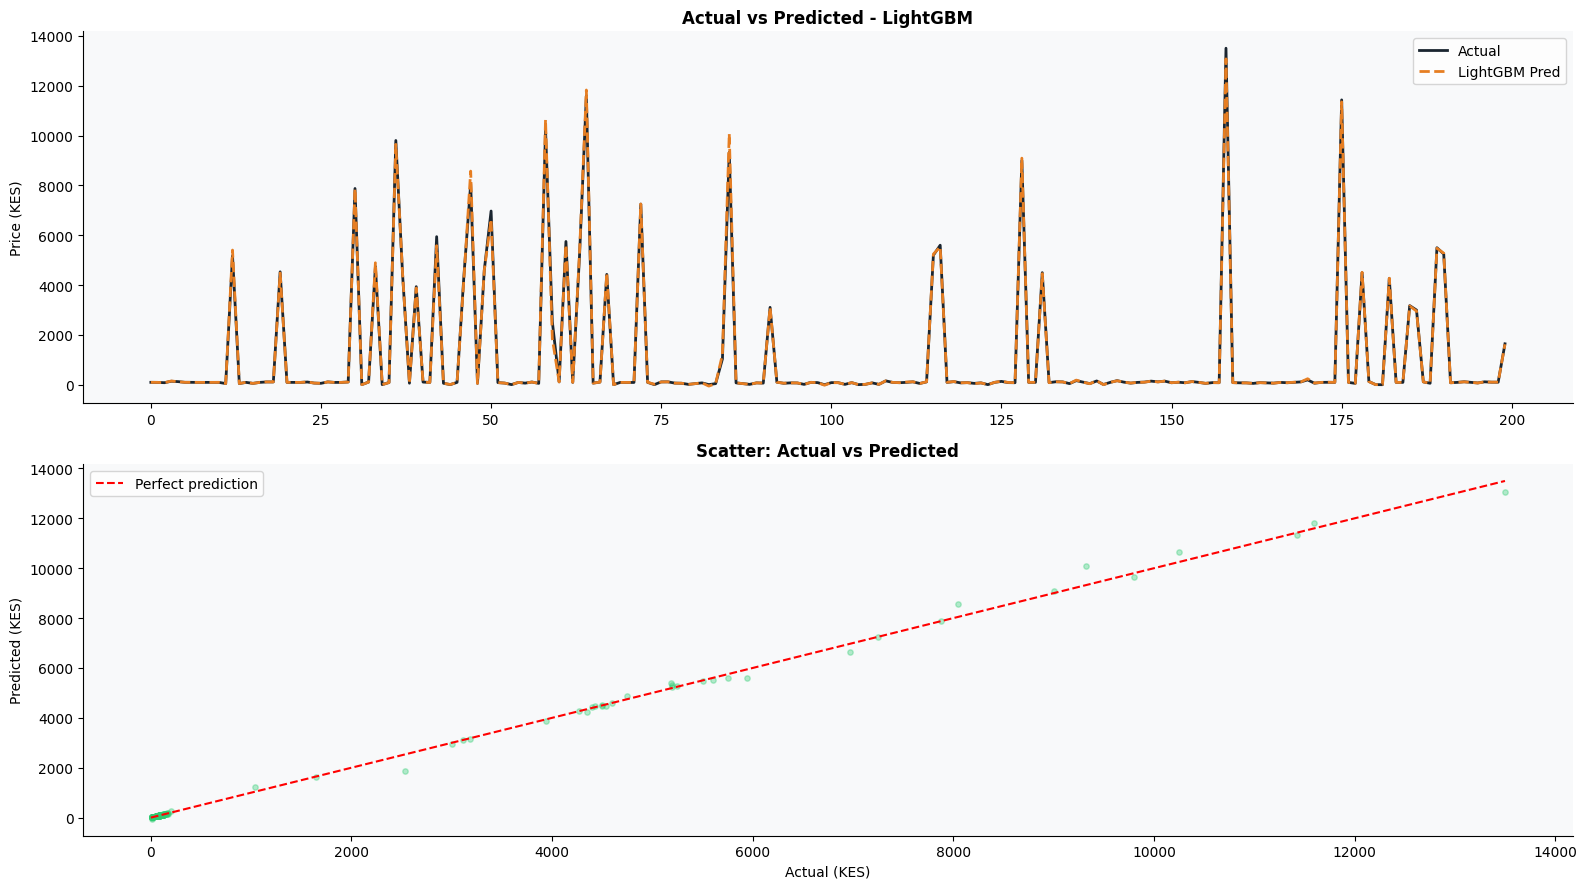

In [32]:
# Viz 12: Actual vs Predicted
best_name = results_df[results_df['Model']!='LSTM'].iloc[0]['Model']
best_pred = predictions[best_name]
n_plot    = min(200, len(y_test))
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
axes[0].plot(range(n_plot), y_test[-n_plot:],   label='Actual',           color=SP_DARK,   lw=2)
axes[0].plot(range(n_plot), best_pred[-n_plot:], label=f'{best_name} Pred', color=SP_ACCENT, lw=2, linestyle='--')
axes[0].set_title(f'Actual vs Predicted - {best_name}', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Price (KES)'); axes[0].legend(); axes[0].set_facecolor('#F8F9FA')
axes[1].scatter(y_test[-n_plot:], best_pred[-n_plot:], alpha=0.35, color=SP_GREEN, s=15)
mx = max(y_test[-n_plot:].max(), best_pred[-n_plot:].max())
axes[1].plot([0,mx],[0,mx],'r--',lw=1.5,label='Perfect prediction')
axes[1].set_title(f'Scatter: Actual vs Predicted', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Actual (KES)'); axes[1].set_ylabel('Predicted (KES)')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz12_actual_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()

These plots visualize the excellent performance of the LightGBM model by comparing its predictions against the actual price. The line chart shows the predicted values (orange) tracking the actual values (blue) almost perfectly across all spikes and drops. The scatter plot confirms this high accuracy, with the data points tightly hugging the dashed perfect prediction line.

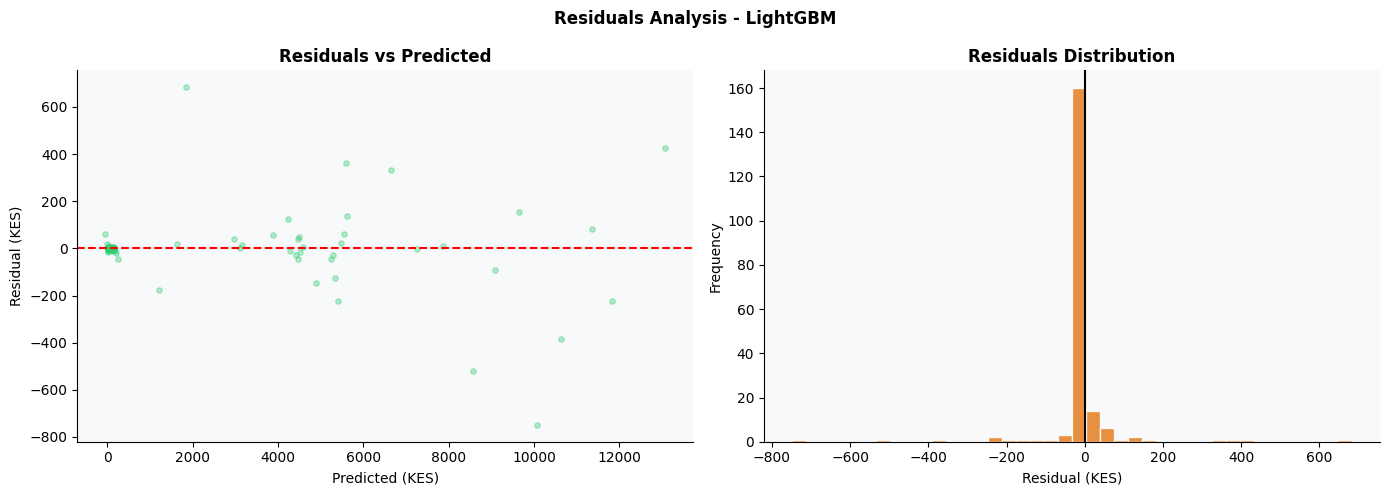

Residual mean: -1.198 KES | std: 103.470 KES


In [33]:
# Viz 13: Residuals
residuals = y_test[-n_plot:] - best_pred[-n_plot:]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(best_pred[-n_plot:], residuals, alpha=0.35, color=SP_GREEN, s=15)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted (KES)'); axes[0].set_ylabel('Residual (KES)'); axes[0].set_facecolor('#F8F9FA')
axes[1].hist(residuals, bins=40, color=SP_ACCENT, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (KES)'); axes[1].set_ylabel('Frequency'); axes[1].set_facecolor('#F8F9FA')
fig.suptitle(f'Residuals Analysis - {best_name}', fontsize=12, fontweight='bold')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz13_residuals.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Residual mean: {residuals.mean():.3f} KES | std: {residuals.std():.3f} KES')

These plots display the residual analysis for the LightGBM model, evaluating its prediction errors. The scatter plot shows that the errors are randomly scattered around zero with a near-zero mean, indicating no systematic bias.

**The histogram** confirms that the residuals are tightly concentrated around zero, forming a sharp, normally distributed peak that shows the model's high precision.


## Phase 10 - SokoPrice Dashboard 

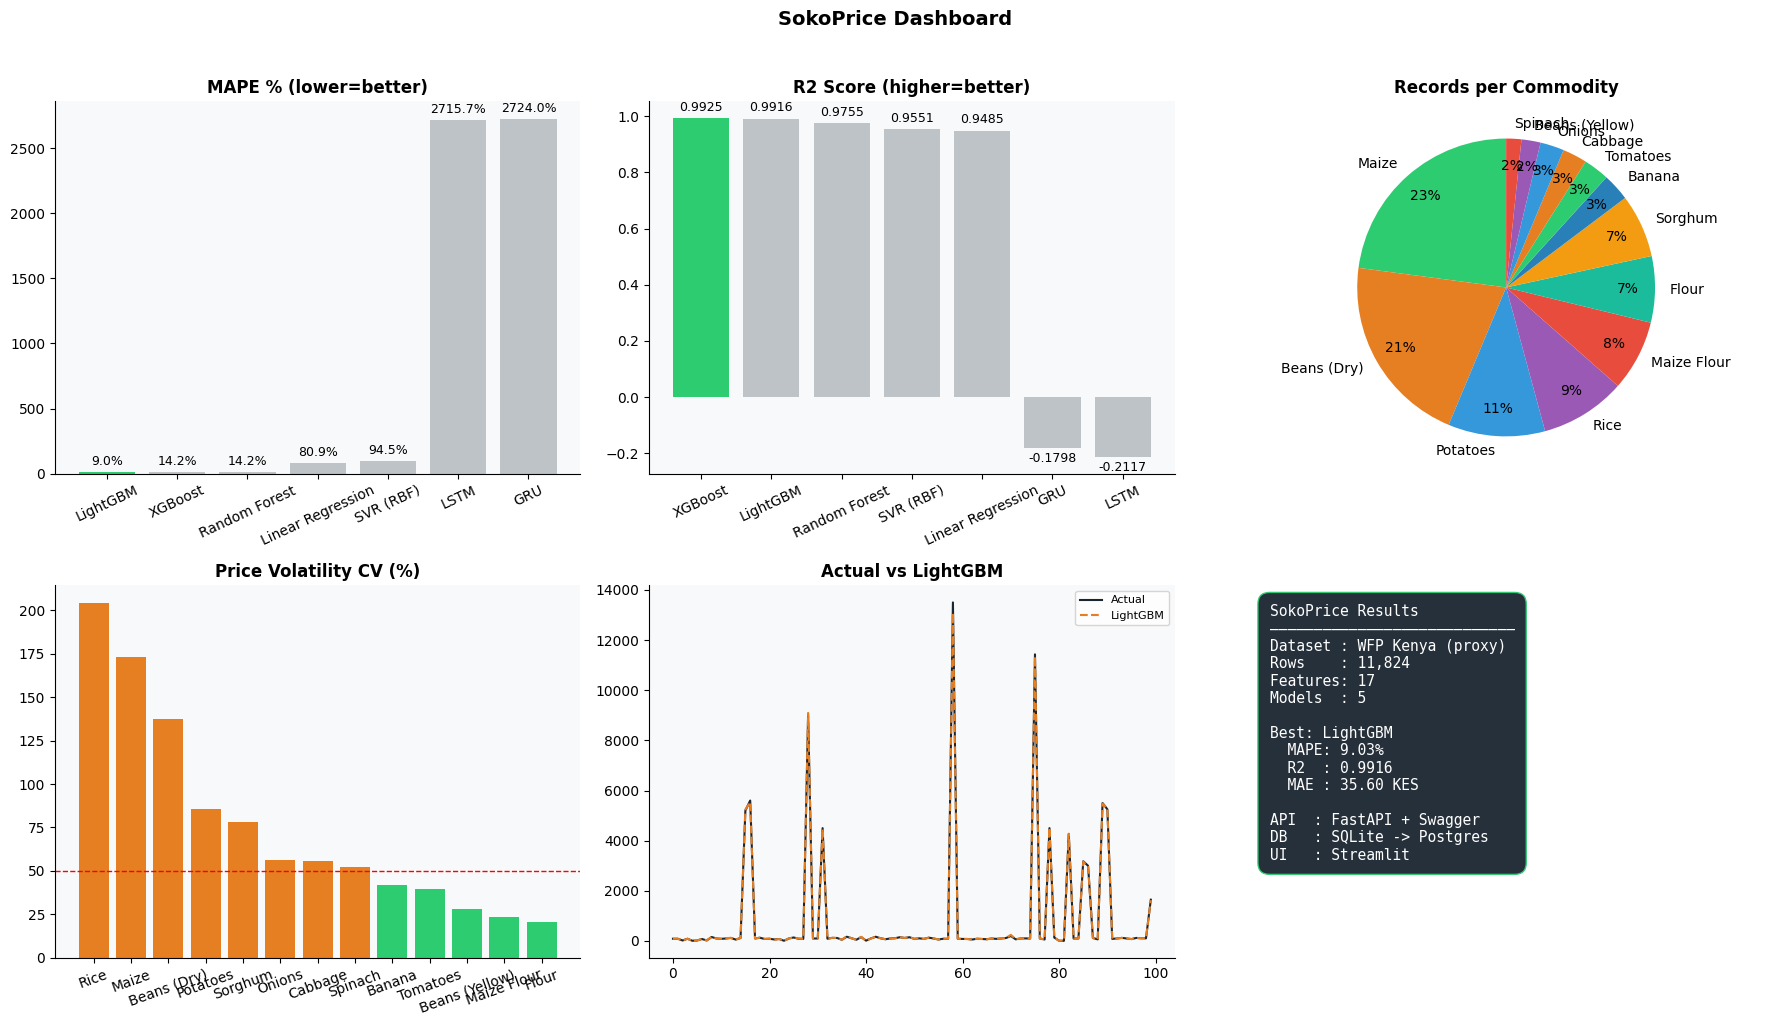

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

df_m = results_df.sort_values('MAPE (%)')
c1   = [SP_GREEN if i==0 else '#BDC3C7' for i in range(len(df_m))]
b1   = axes[0].bar(df_m['Model'], df_m['MAPE (%)'], color=c1)
axes[0].bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_title('MAPE % (lower=better)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25); axes[0].set_facecolor('#F8F9FA')

df_r = results_df.sort_values('R2', ascending=False)
c2   = [SP_GREEN if i==0 else '#BDC3C7' for i in range(len(df_r))]
b2   = axes[1].bar(df_r['Model'], df_r['R2'], color=c2)
axes[1].bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
axes[1].set_title('R2 Score (higher=better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25); axes[1].set_facecolor('#F8F9FA')

comm_counts = df_target['commodity_label'].value_counts()
axes[2].pie(comm_counts.values, labels=comm_counts.index, colors=PALETTE[:len(comm_counts)],
            autopct='%1.0f%%', startangle=90, pctdistance=0.82)
axes[2].set_title('Records per Commodity', fontweight='bold')

c4 = [SP_ACCENT if v > 50 else SP_GREEN for v in volatility['cv']]
axes[3].bar(volatility['commodity_label'], volatility['cv'], color=c4)
axes[3].axhline(50, color='red', linestyle='--', lw=1)
axes[3].set_title('Price Volatility CV (%)', fontweight='bold')
axes[3].tick_params(axis='x', rotation=20); axes[3].set_facecolor('#F8F9FA')

n100 = min(100, len(y_test))
axes[4].plot(y_test[-n100:],    lw=1.5, color=SP_DARK,   label='Actual')
axes[4].plot(best_pred[-n100:], lw=1.5, color=SP_ACCENT, linestyle='--', label=best_name)
axes[4].set_title(f'Actual vs {best_name}', fontweight='bold')
axes[4].legend(fontsize=8); axes[4].set_facecolor('#F8F9FA')

axes[5].axis('off')
summary = (f'SokoPrice Results\n{chr(8212)*28}\n'
           f'Dataset : WFP Kenya (proxy)\n'
           f'Rows    : {df_ml.shape[0]:,}\n'
           f'Features: {len(FEATURE_COLS)}\nModels  : 5\n\n'
           f'Best: {best["Model"]}\n'
           f'  MAPE: {best["MAPE (%)"]:.2f}%\n'
           f'  R2  : {best["R2"]:.4f}\n'
           f'  MAE : {best["MAE"]:.2f} KES\n\n'
           f'API  : FastAPI + Swagger\nDB   : SQLite -> Postgres\nUI   : Streamlit')
axes[5].text(0.05, 0.95, summary, transform=axes[5].transAxes,
             fontsize=10.5, verticalalignment='top', fontfamily='monospace', color='white',
             bbox=dict(boxstyle='round,pad=0.8', facecolor=SP_DARK, edgecolor=SP_GREEN, alpha=0.95))

fig.suptitle('SokoPrice Dashboard', fontsize=14, fontweight='bold', y=1.02)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('sokoprice_dashboard.png', dpi=150, bbox_inches='tight'); plt.show()

This SokoPrice dashboard consolidates the project's model performance, data distribution, and technical details. The charts confirm LightGBM as the top model, achieving a 0.9916 R2 score with the lowest error rates. 

**The Pie Chart** shows the breakdown of records  per commodity.